In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

In [77]:
# 1) LOAD
control_df = pd.read_csv("../data/Salmonella Enteretidis_Control.csv")
lmf_df = pd.read_csv("../data/Salmonella Enteretidis_LMF.csv")
control_df["phenotype"] = "Control"
lmf_df["phenotype"] = "LMF"
df = pd.concat([control_df, lmf_df], ignore_index=True)

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_7600\796417123.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lmf_sources.values, y=lmf_sources.index, palette='viridis', ax=ax2)


Figure 1 Final Clean generated.


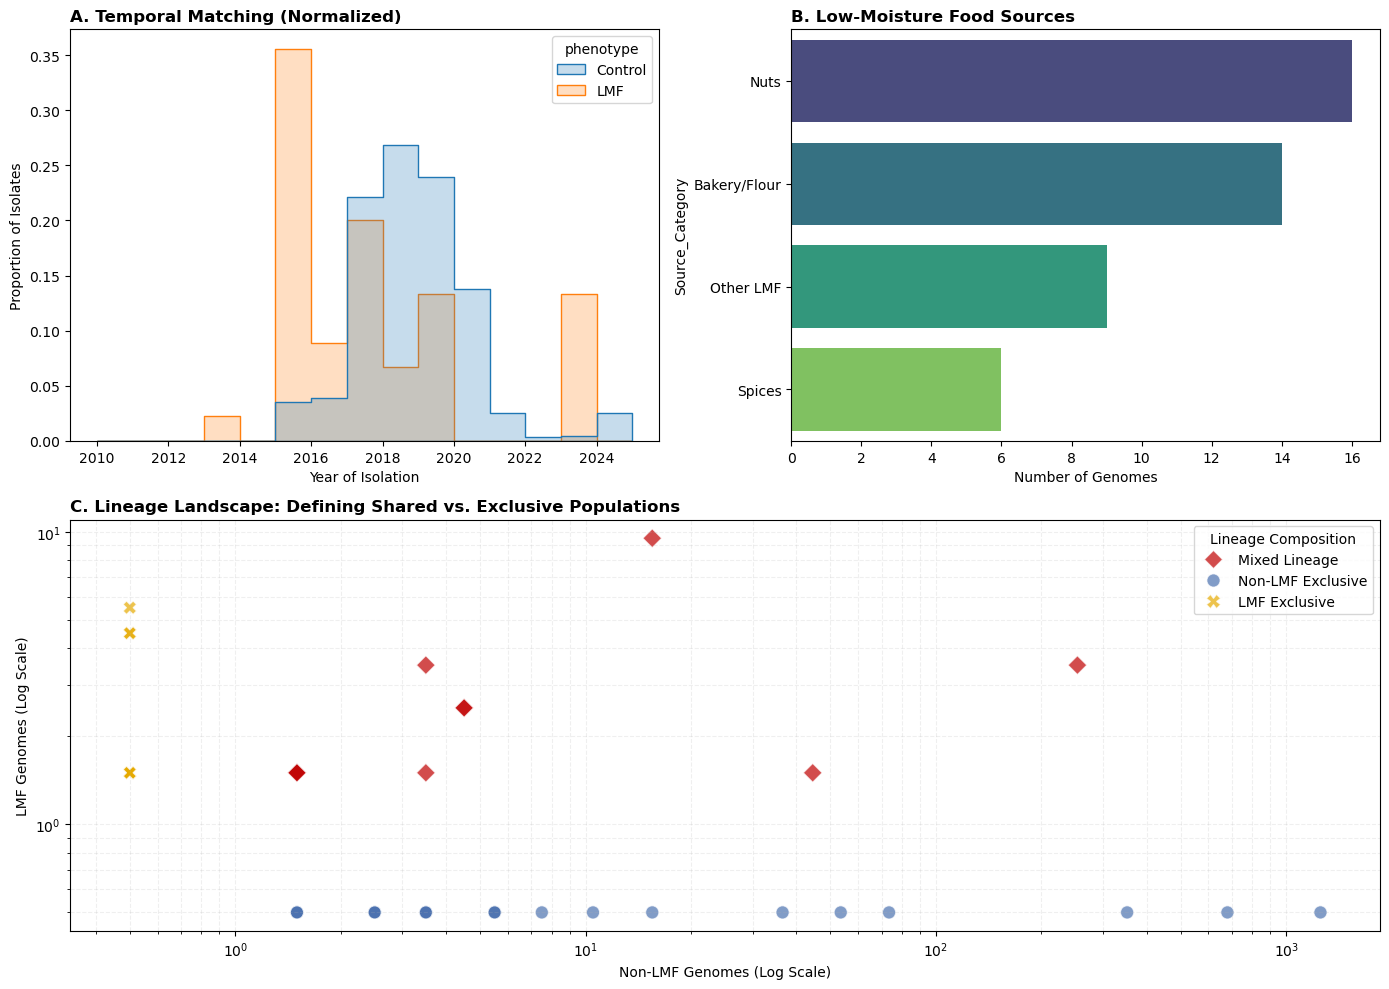

In [71]:
# 2. FILTER
df = df[(df["#Organism group"] == "Salmonella enterica") & (df["Serovar"] == "Enteritidis")]
df = df[~df["Isolation type"].astype(str).str.lower().str.contains("clinical", na=False)]
valid_computed = df["Computed types"].astype(str).str.contains(r"serotype=Enteritidis", case=False, na=False)
df_final = df[valid_computed].copy()
df_final = df_final[df_final["SNP cluster"].notna()].copy()

# 3. PREPARE PLOTTING DATA
# A. Temporal
df_final['Year'] = pd.to_datetime(df_final['Create date']).dt.year

# B. Source Categories
def get_source_category(row):
    s = str(row['Isolation source']).lower()
    if row['phenotype'] == 'Control':
        return 'Poultry (Control)'
    if any(x in s for x in ['almond', 'pistachio', 'nut', 'pecan', 'walnut']): return 'Nuts'
    if any(x in s for x in ['spice', 'pepper', 'cumin', 'powder', 'chili', 'seasoning']): return 'Spices'
    if any(x in s for x in ['flour', 'cake', 'cookie', 'bakery', 'wheat']): return 'Bakery/Flour'
    return 'Other LMF'

df_final['Source_Category'] = df_final.apply(get_source_category, axis=1)

# C. Cluster Data
cluster_counts = df_final.groupby(["SNP cluster", "phenotype"]).size().unstack(fill_value=0)
for col in ["LMF", "Control"]:
    if col not in cluster_counts.columns: cluster_counts[col] = 0

# Define explicit types - UPDATED NAMES per user request
conditions = [
    (cluster_counts['LMF'] > 0) & (cluster_counts['Control'] > 0),
    (cluster_counts['LMF'] > 0) & (cluster_counts['Control'] == 0),
    (cluster_counts['LMF'] == 0) & (cluster_counts['Control'] > 0)
]
# Changed 'Poultry Exclusive' to 'Non-LMF Exclusive'
choices = ['Mixed Lineage', 'LMF Exclusive', 'Non-LMF Exclusive']
cluster_counts['Lineage_Type'] = np.select(conditions, choices, default='Unknown')

# Pseudo-count for plotting
cluster_counts['LMF_plot'] = cluster_counts['LMF'] + 0.5
cluster_counts['Control_plot'] = cluster_counts['Control'] + 0.5

# 4. PLOT COMPOSITE FIGURE
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

# Panel A: Temporal Distribution (Normalized)
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(
    data=df_final, x='Year', hue='phenotype', 
    element='step', stat='probability', common_norm=False, 
    bins=range(2010, 2026), ax=ax1
)
ax1.set_title('A. Temporal Matching (Normalized)', loc='left', fontweight='bold')
ax1.set_ylabel('Proportion of Isolates')
ax1.set_xlabel('Year of Isolation')

# Panel B: LMF Sources
ax2 = fig.add_subplot(gs[0, 1])
lmf_sources = df_final[df_final['phenotype']=='LMF']['Source_Category'].value_counts()
sns.barplot(x=lmf_sources.values, y=lmf_sources.index, palette='viridis', ax=ax2)
ax2.set_title('B. Low-Moisture Food Sources', loc='left', fontweight='bold')
ax2.set_xlabel('Number of Genomes')

# Panel C: Lineage Landscape - UPDATED per user request
ax3 = fig.add_subplot(gs[1, :])

# User's Custom Palette
custom_palette = {
    'Non-LMF Exclusive': '#4c72b0', # Stronger Blue
    'LMF Exclusive': '#e6aa00',     # Stronger Mustard/Orange
    'Mixed Lineage': '#c00000'      # Deep Red
}

# Update markers to match new keys
custom_markers = {
    'Non-LMF Exclusive': 'o', 
    'LMF Exclusive': 'X', 
    'Mixed Lineage': 'D'
}

sns.scatterplot(
    data=cluster_counts, 
    x='Control_plot', y='LMF_plot', 
    hue='Lineage_Type', style='Lineage_Type',
    palette=custom_palette,
    markers=custom_markers,
    s=90, alpha=0.7, ax=ax3
)
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.set_title('C. Lineage Landscape: Defining Shared vs. Exclusive Populations', loc='left', fontweight='bold')
ax3.set_xlabel('Non-LMF Genomes (Log Scale)')
ax3.set_ylabel('LMF Genomes (Log Scale)')
ax3.grid(True, which="both", ls="--", alpha=0.2)
ax3.legend(title='Lineage Composition')

# NO TEXT ANNOTATIONS (per user request)

plt.tight_layout()
plt.savefig('Figure1_Final_Clean.tiff')
print("Figure 1 Final Clean generated.")

In [81]:
cluster_counts[cluster_counts['Lineage_Type']=='Mixed Lineage']

phenotype,Control,LMF,Lineage_Type,LMF_plot,Control_plot
SNP cluster,,,,,
PDS000002770.694,3,3,Mixed Lineage,3.5,3.5
PDS000026860.270,3,1,Mixed Lineage,1.5,3.5
PDS000026869.554,44,1,Mixed Lineage,1.5,44.5
PDS000026945.72,4,2,Mixed Lineage,2.5,4.5
PDS000043097.1,1,1,Mixed Lineage,1.5,1.5
PDS000058525.21,1,1,Mixed Lineage,1.5,1.5
PDS000065758.1669,253,3,Mixed Lineage,3.5,253.5
PDS000084711.573,1,1,Mixed Lineage,1.5,1.5
PDS000184417.155,4,2,Mixed Lineage,2.5,4.5


In [83]:
cluster_counts['Lineage_Type'].value_counts()

Lineage_Type
Non-LMF Exclusive    30
LMF Exclusive        11
Mixed Lineage        10
Name: count, dtype: int64